### Importação das bibliotecas da webmotors

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Bibliotecas de Machine Learning

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction import FeatureHasher

### Leitura dos dados 

In [4]:
webmotors = pd.read_excel('webmotors.xlsx') 
webmotors

,cod_anuncio,cod_cliente,cod_tipo_pessoa,prioridade,leads,views,cliques_telefone*,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,...,arquente,bancocouro,arcondic,abs,desembtras,travaeletr,vidroseletr,rodasliga,sensorchuva,sensorestacion
0,2,7941,2,3,1,0,0,34,769,346932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,1770,1,3,1,0,4,2,704,340148,...,S,N,N,S,N,S,S,N,N,N
2,8,709,1,3,4,0,11,30,1071,310713,...,S,N,S,S,S,S,S,S,N,N
3,13,9708,1,2,12,0,14,10,2028,341195,...,S,S,S,N,N,S,S,S,N,N
4,15,1363,1,2,8,0,11,12,805,332063,...,S,S,S,S,S,S,S,S,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48660,195918,3065,2,3,1,34184,0,280,3365,346359,...,S,S,S,S,S,S,S,S,N,S
48661,195924,12535,2,3,1,45048,0,4,1177,343882,...,N,N,N,N,N,N,N,N,N,N
48662,195930,2284,2,3,1,71020,0,5,3128,344252,...,N,N,N,N,N,N,N,N,N,N
48663,195934,2284,2,3,0,82940,0,2,3323,344421,...,S,N,S,N,S,S,S,S,N,N


### Organização das colunas para obter Dimensões e fatos 

*** Dimensão de Anunciante

In [5]:
Dim_Anunciante = pd.DataFrame({
    
    "cod_cliente": webmotors["cod_cliente"],
    "cod_tipo_pessoa":  webmotors["cod_tipo_pessoa"],
    "uf_cidade": webmotors["uf_cidade"]
})

In [6]:
## Verificação de dados nulos
Dim_Anunciante.isna().sum()

cod_cliente        0
cod_tipo_pessoa    0
uf_cidade          0
dtype: int64

In [7]:
### Verificação de dados duplicados 
Dim_Anunciante = Dim_Anunciante = Dim_Anunciante.drop_duplicates() 
Dim_Anunciante_count = Dim_Anunciante.count()[0]

In [8]:
pd.DataFrame({"Total de Anunciantes" : [Dim_Anunciante_count]})

,Total de Anunciantes
0,16306


In [9]:
Dim_Anunciante

,cod_cliente,cod_tipo_pessoa,uf_cidade
0,7941,2,GO_Itumbiara
1,1770,1,SP_Osasco
2,709,1,SP_São Paulo
3,9708,1,SP_São Paulo
4,1363,1,SP_São Paulo
...,...,...,...
48631,8780,2,SP_São Bernardo do Campo
48641,38733,1,SP_Campo Limpo Paulista
48646,939,1,SP_São Paulo
48656,4721,2,SP_Osazca


*** Dimensão de Veículo 

In [10]:
Dim_Veiculo = pd.DataFrame({
    
    "cod_marca_veiculo": webmotors["cod_marca_veiculo"], 
    "cod_modelo_veiculo": webmotors["cod_modelo_veiculo"], 
    "cod_versao_veiculo": webmotors["cod_versao_veiculo"], 
    "combustivel": webmotors["combustivel"], 
    "cambio": webmotors["cambio"], 
    "portas": webmotors["portas"], 
    "alarme": webmotors["alarme"], 
    "airbag": webmotors["airbag"], 
    "arquente": webmotors["arquente"], 
    "bancocouro": webmotors["bancocouro"], 
    "arcondic": webmotors["arcondic"], 
    "abs": webmotors["abs"], 
    "desembtras": webmotors["desembtras"], 
    "travaeletr": webmotors["travaeletr"], 
    "vidroseletr": webmotors["vidroseletr"], 
    "rodasliga": webmotors["rodasliga"], 
    "sensorchuva": webmotors["sensorchuva"], 
    "sensorestacion": webmotors["sensorestacion"]
})

In [11]:
## Verificação de dados nulos
Dim_Veiculo.isna().sum()

cod_marca_veiculo     0
cod_modelo_veiculo    0
cod_versao_veiculo    0
combustivel           1
cambio                1
portas                1
alarme                1
airbag                8
arquente              1
bancocouro            1
arcondic              1
abs                   1
desembtras            1
travaeletr            1
vidroseletr           1
rodasliga             1
sensorchuva           1
sensorestacion        1
dtype: int64

In [12]:
Dim_Veiculo = Dim_Veiculo.dropna()

In [13]:
### Verificando dados duplicados
Dim_Veiculo.duplicated().sum()

19076

In [14]:
### Removendo dados duplicados
Dim_Veiculo = Dim_Veiculo.drop_duplicates() 
Dim_Veiculo_count = Dim_Veiculo.count()[0]

In [15]:
pd.DataFrame({"Total de Veículos" : [Dim_Veiculo_count]})

,Total de Veículos
0,29581


In [16]:
Dim_Veiculo

,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,combustivel,cambio,portas,alarme,airbag,arquente,bancocouro,arcondic,abs,desembtras,travaeletr,vidroseletr,rodasliga,sensorchuva,sensorestacion
3,10,2028,341195,gasolina,automatico,2.0,N,S,S,S,S,N,N,S,S,S,N,N
4,12,805,332063,gasolina,automatico,4.0,S,N,S,S,S,S,S,S,S,S,N,N
6,3,2497,333017,gasolina,manual,2.0,N,N,N,S,N,N,N,N,N,S,N,N
9,2,1143,337123,gasolina,manual,2.0,S,N,N,N,N,N,N,S,S,S,N,N
10,3,2191,339963,gasolina,manual,2.0,N,N,N,S,N,N,N,N,N,S,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48655,2,3340,346815,gasolina e alcool,manual,4.0,S,N,N,N,S,N,N,S,S,N,N,N
48656,17,3260,343942,gasolina,automatico,3.0,N,S,S,S,S,S,S,S,S,S,N,S
48659,25,3474,345807,gasolina,automatico,4.0,N,N,S,N,S,N,S,S,S,S,N,S
48663,2,3323,344421,gasolina e alcool,automatico,4.0,S,N,S,N,S,N,S,S,S,S,N,N


*** Dimensão Anuncio_Detalhes

In [17]:
Dim_Anuncio_Detalhes = pd.DataFrame({
    
    "cod_anuncio": webmotors["cod_anuncio"], 
    "flg_unico_dono": webmotors["flg_unico_dono"], 
    "flg_licenciado": webmotors["flg_licenciado"], 
    "flg_ipva_pago": webmotors["flg_ipva_pago"], 
    "flg_todas_revisoes_concessionaria": webmotors["flg_todas_revisoes_concessionaria"], 
    "flg_todas_revisoes_agenda_veiculo": webmotors["flg_todas_revisoes_agenda_veiculo"], 
    "flg_garantia_fabrica": webmotors["flg_garantia_fabrica"], 
    "flg_blindado": webmotors["flg_blindado"], 
    "flg_aceita_troca": webmotors["flg_aceita_troca"], 
    "flg_adaptado_pcd": webmotors["flg_adaptado_pcd"], 
    "qtd_fotos": webmotors["qtd_fotos"]
})

In [18]:
### Verificação de dados nulos
Dim_Anuncio_Detalhes.isna().sum()

cod_anuncio                            0
flg_unico_dono                         0
flg_licenciado                         0
flg_ipva_pago                        312
flg_todas_revisoes_concessionaria    312
flg_todas_revisoes_agenda_veiculo      0
flg_garantia_fabrica                 312
flg_blindado                           0
flg_aceita_troca                       0
flg_adaptado_pcd                     312
qtd_fotos                              0
dtype: int64

In [19]:
### Apagando dados NAN 
Dim_Anuncio_Detalhes = Dim_Anuncio_Detalhes.dropna()

In [20]:
## Verificando dados duplicados
Dim_Anuncio_Detalhes.duplicated().sum()

0

In [21]:
Dim_Anuncio_Detalhes

,cod_anuncio,flg_unico_dono,flg_licenciado,flg_ipva_pago,flg_todas_revisoes_concessionaria,flg_todas_revisoes_agenda_veiculo,flg_garantia_fabrica,flg_blindado,flg_aceita_troca,flg_adaptado_pcd,qtd_fotos
0,2,0,0,0.0,0.0,0,0.0,0,0,0.0,7
1,6,0,0,0.0,0.0,0,0.0,0,0,0.0,0
2,8,0,0,0.0,0.0,0,0.0,0,0,0.0,4
3,13,0,1,1.0,0.0,0,0.0,0,0,0.0,8
4,15,0,0,0.0,0.0,0,0.0,0,0,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...
48608,39496,0,0,1.0,0.0,0,0.0,0,1,0.0,8
48609,39620,0,1,1.0,1.0,1,0.0,0,1,0.0,6
48611,39761,0,1,1.0,1.0,1,1.0,0,1,0.0,8
48644,43573,1,0,1.0,1.0,1,0.0,0,0,0.0,8


*** Fatos_Anuncios

In [22]:
Fato_Anuncio = pd.DataFrame({
    
    "cod_anuncio": webmotors["cod_anuncio"], 
    "cod_cliente": webmotors["cod_cliente"], 
    "cod_marca_veiculo": webmotors["cod_marca_veiculo"], 
    "cod_modelo_veiculo": webmotors["cod_modelo_veiculo"], 
    "cod_versao_veiculo": webmotors["cod_versao_veiculo"], 
    "ano_modelo": webmotors["ano_modelo"], 
    "cep_2dig": webmotors["cep_2dig"], 
    "vlr_anuncio": webmotors["vlr_anuncio"], 
    "km_veiculo": webmotors["km_veiculo"], 
    "vlr_mercado": webmotors["vlr_mercado"], 
    "leads": webmotors["leads"], 
    "views": webmotors["views"], 
    "prioridade": webmotors["prioridade"],
    "cliques_telefone": webmotors["cliques_telefone*"]
})

In [23]:
### Verificação de dados nulos
Fato_Anuncio.isna().sum()

cod_anuncio              0
cod_cliente              0
cod_marca_veiculo        0
cod_modelo_veiculo       0
cod_versao_veiculo       0
ano_modelo               0
cep_2dig                 0
vlr_anuncio              0
km_veiculo               0
vlr_mercado           6217
leads                    0
views                    0
prioridade               0
cliques_telefone         0
dtype: int64

In [24]:
### Apagando dados NAN de Fatos
Fato_Anuncio = Fato_Anuncio.dropna()

In [25]:
### Verificação de dados duplicados
Fato_Anuncio.duplicated().sum()

0

In [26]:
Fato_Anuncio

,cod_anuncio,cod_cliente,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,ano_modelo,cep_2dig,vlr_anuncio,km_veiculo,vlr_mercado,leads,views,prioridade,cliques_telefone
9,31,13771,2,1143,337123,2004,9,10900,99999,1.248147e+09,16,0,2,8
12,43,15847,17,2600,339076,2010,18,62500,13500,3.391296e+09,1,0,1,10
16,55,15375,16,690,342914,2010,2,38999,102000,3.966190e+09,104,0,1,72
25,95,16462,12,2722,342061,2010,8,31900,74000,2.687501e+09,0,0,1,6
28,110,1987,2,1161,339241,2009,1,25500,128000,2.377945e+09,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48660,195918,3065,280,3365,346359,2016,17,48000,35000,4.801133e+09,1,34184,3,0
48661,195924,12535,4,1177,343882,2013,25,42999.99,91222,4.308533e+08,1,45048,3,0
48662,195930,2284,5,3128,344252,2012,13,93900,120000,8.169657e+09,1,71020,3,0
48663,195934,2284,2,3323,344421,2014,13,53800,40000,4.580401e+08,0,82940,3,0


In [27]:
### Resolvendo um problema da coluna vlr_mercado da coluna Fato_Anuncio
### vlr_mercado = 1.248147e+09

print(Fato_Anuncio['vlr_mercado'].dtype)

float64


In [28]:
### Conversão de Valores
Fato_Anuncio["vlr_mercado"] = pd.to_numeric(Fato_Anuncio['vlr_mercado'], errors='coerce')

In [29]:
### Formatar para Exibição 
pd.options.display.float_format = '{:,.2f}'.format

In [30]:
# Verificando valores nulos
print(Fato_Anuncio['vlr_mercado'].isna().sum())

0


In [31]:
# Removendo linhas com valores nulos na coluna 'vlr_mercado'
Fato_Anuncio = Fato_Anuncio.dropna(subset=['vlr_mercado'])

In [32]:
# Filtrando valores anômalos, por exemplo, valores extremamente altos ou baixos
Fato_Anuncio = Fato_Anuncio[(Fato_Anuncio['vlr_mercado'] > 0) & (Fato_Anuncio['vlr_mercado'] < 1e10)]
Fato_Anuncio

,cod_anuncio,cod_cliente,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,ano_modelo,cep_2dig,vlr_anuncio,km_veiculo,vlr_mercado,leads,views,prioridade,cliques_telefone
9,31,13771,2,1143,337123,2004,9,10900,99999,"1,248,147,182.00",16,0,2,8
12,43,15847,17,2600,339076,2010,18,62500,13500,"3,391,296,306.00",1,0,1,10
16,55,15375,16,690,342914,2010,2,38999,102000,"3,966,190,212.00",104,0,1,72
25,95,16462,12,2722,342061,2010,8,31900,74000,"2,687,500,573.00",0,0,1,6
28,110,1987,2,1161,339241,2009,1,25500,128000,"2,377,945,322.00",0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48660,195918,3065,280,3365,346359,2016,17,48000,35000,"4,801,133,387.00",1,34184,3,0
48661,195924,12535,4,1177,343882,2013,25,"42,999.99",91222,"430,853,255.00",1,45048,3,0
48662,195930,2284,5,3128,344252,2012,13,93900,120000,"8,169,656,707.00",1,71020,3,0
48663,195934,2284,2,3323,344421,2014,13,53800,40000,"458,040,133.00",0,82940,3,0


In [33]:
### Resumo estatístico de Dim_Anuncio_Detalhes 
Dim_Anuncio_Detalhes.describe()

,cod_anuncio,flg_unico_dono,flg_licenciado,flg_ipva_pago,flg_todas_revisoes_concessionaria,flg_todas_revisoes_agenda_veiculo,flg_garantia_fabrica,flg_blindado,flg_aceita_troca,flg_adaptado_pcd,qtd_fotos
count,"48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00","48,353.00"
mean,"97,685.26",0.21,0.30,0.40,0.15,0.07,0.09,0.02,0.09,0.00,6.63
std,"56,144.28",0.41,0.46,0.49,0.36,0.25,0.28,0.14,0.28,0.02,2.17
min,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"49,240.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00
50%,"97,379.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00
75%,"146,446.00",0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,8.00
max,"194,701.00",1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,20.00


In [34]:
### Resumo estatístico de Fato_Anuncio 
Fato_Anuncio.describe()

,cod_anuncio,cod_cliente,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,ano_modelo,cep_2dig,km_veiculo,vlr_mercado,leads,views,prioridade,cliques_telefone
count,"42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00","42,448.00"
mean,"101,121.54","8,430.90",18.67,"2,071.22","343,140.92","2,013.50",38.38,"283,010.31","3,783,526,702.64",4.18,465.87,2.61,7.02
std,"55,584.16","7,574.14",36.46,"1,110.63","8,527.95",3.47,33.57,"18,131,940.05","2,226,691,244.21",11.54,"1,154.88",0.77,10.96
min,31.00,1.00,2.00,650.00,"1,429.00","1,951.00",1.00,0.00,"17,353.38",0.00,0.00,1.00,0.00
25%,"53,631.75","3,581.00",4.00,788.00,"342,625.00","2,012.00",9.00,"34,000.00","2,230,601,718.50",1.00,84.00,3.00,2.00
50%,"101,719.50","6,599.00",5.00,"2,487.00","344,130.00","2,014.00",22.00,"59,448.00","3,570,274,575.00",1.00,208.00,3.00,4.00
75%,"149,455.00","10,181.00",26.00,"3,202.00","345,485.00","2,016.00",78.00,"89,540.25","4,993,826,885.00",4.00,476.00,3.00,8.00
max,"195,939.00","38,733.00",304.00,"3,676.00","347,728.00","2,019.00",99.00,"2,147,483,647.00","9,999,020,387.00",364.00,"93,608.00",3.00,457.00


In [35]:
### Resumo estatístico da vlr_mercado
Fato_Anuncio["vlr_mercado"].describe()

count          42,448.00
mean    3,783,526,702.64
std     2,226,691,244.21
min            17,353.38
25%     2,230,601,718.50
50%     3,570,274,575.00
75%     4,993,826,885.00
max     9,999,020,387.00
Name: vlr_mercado, dtype: float64

<AxesSubplot:xlabel='vlr_mercado', ylabel='Count'>

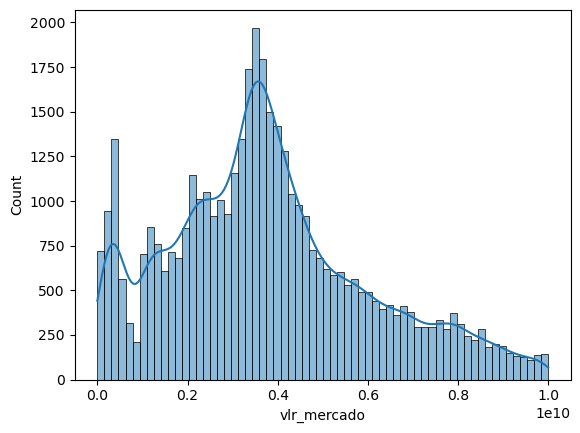

In [36]:
### Histograma da variável mercado 
sns.histplot(data = Fato_Anuncio, x = "vlr_mercado", kde = True)

In [37]:
## Correlação entre as variáveis 
correlation_matrix = Fato_Anuncio.corr()

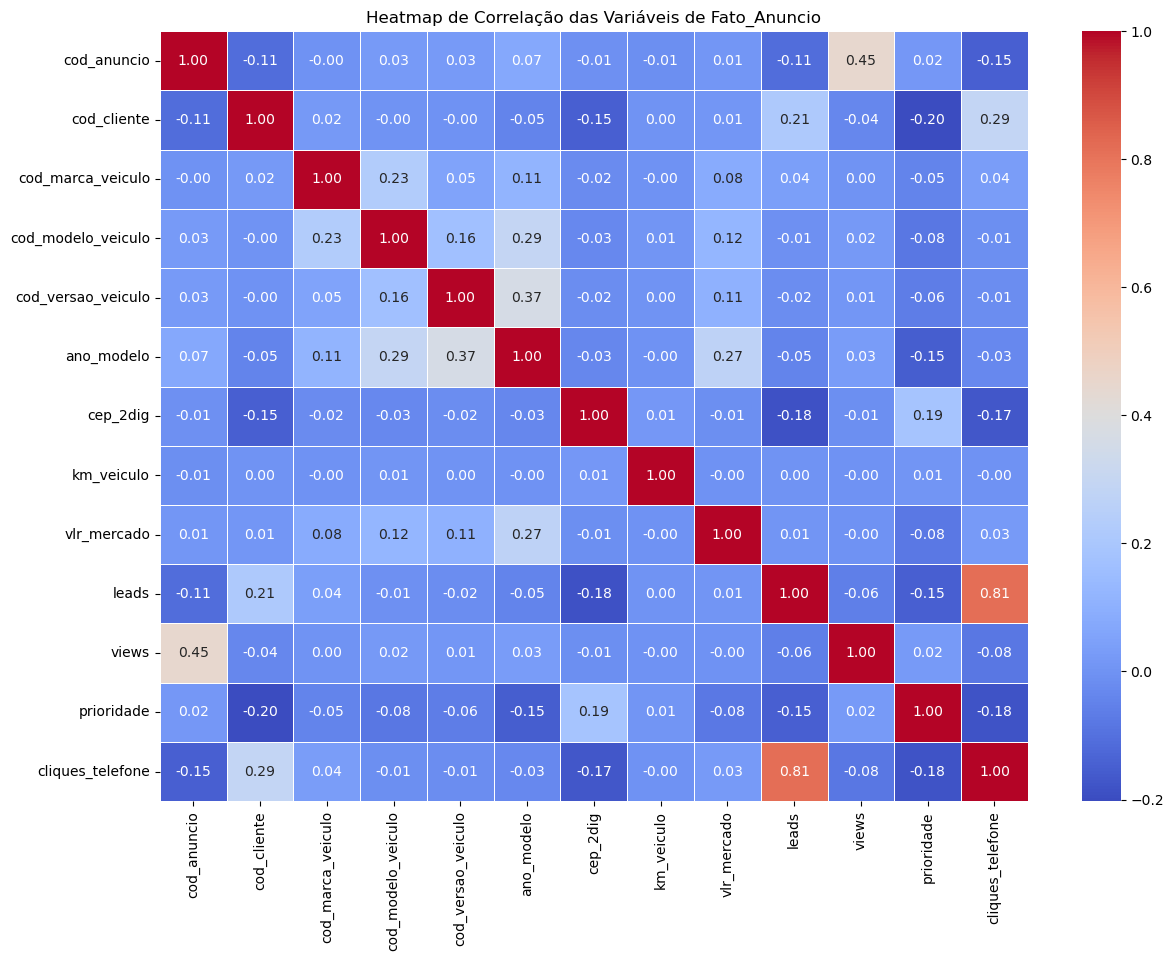

In [38]:
## Plotar o heatmap 
plt.figure(figsize=(14,10)) 
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5) 
plt.title("Heatmap de Correlação das Variáveis de Fato_Anuncio") 
plt.show()

### Analisando gráficos de dispersão para variáveis de interesse 

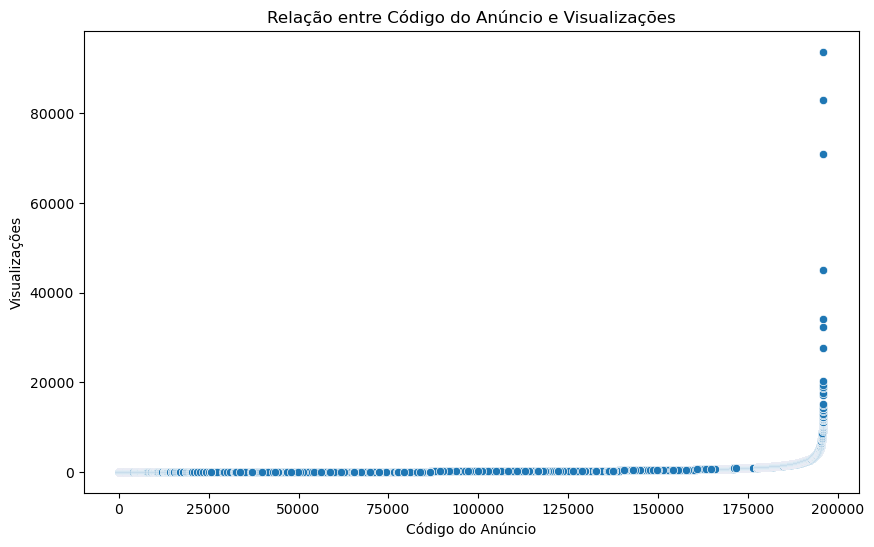

In [39]:
## Gráfico de dispersão para views e cod_anuncio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cod_anuncio', y='views', data=Fato_Anuncio)
plt.title("Relação entre Código do Anúncio e Visualizações") 
plt.xlabel("Código do Anúncio") 
plt.ylabel("Visualizações")
plt.show()

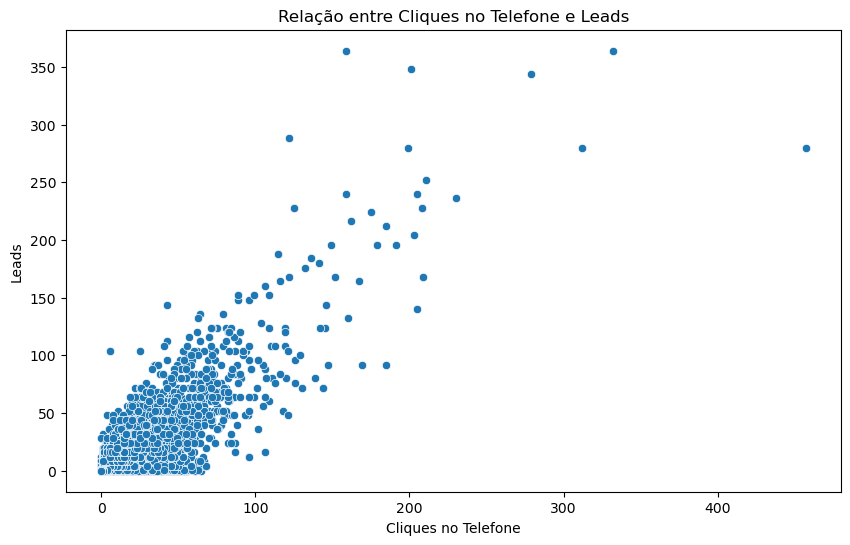

In [40]:
### Gráfico de dispersão para leads e cliques_telefone 
plt.figure(figsize=(10,6))
sns.scatterplot(x='cliques_telefone', y='leads', data=Fato_Anuncio)
plt.title("Relação entre Cliques no Telefone e Leads") 
plt.xlabel("Cliques no Telefone") 
plt.ylabel("Leads") 
plt.show()

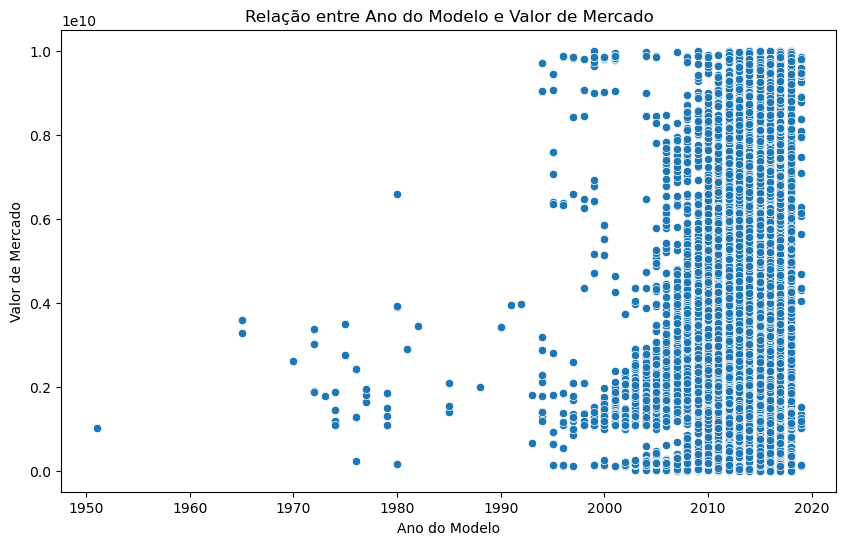

In [41]:
# Gráfico de dispersão para vlr_mercado e ano_modelo
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ano_modelo', y='vlr_mercado', data=Fato_Anuncio)
plt.title("Relação entre Ano do Modelo e Valor de Mercado") 
plt.xlabel("Ano do Modelo")
plt.ylabel("Valor de Mercado") 
plt.show()

### Conexão para o banco de dados 

In [42]:
dbconn = sqlite3.connect('webmotors.db')

### Ativação do suporte a chaves Estrangeiras

In [43]:
print(dbconn)

### Criação da tabela - Dim_Anunciante

In [44]:
dbconn.execute(
    '''
        CREATE TABLE Dim_Anunciante(
            
            cod_cliente INTEGER PRIMARY KEY, 
            cod_tipo_pessoa INTEGER,
            "uf_cidade" TEXT
        )
    '''
)

Dim_Anunciante.to_sql("Dim_Anunciante", dbconn, if_exists='replace', index=False)

OperationalError: table Dim_Anunciante already exists

In [45]:
### Consulta da Tabela 
pd.read_sql_query("SELECT * FROM Dim_Anunciante", con=dbconn)

,cod_cliente,cod_tipo_pessoa,uf_cidade
0,7941,2,GO_Itumbiara
1,1770,1,SP_Osasco
2,709,1,SP_São Paulo
3,9708,1,SP_São Paulo
4,1363,1,SP_São Paulo
...,...,...,...
16301,8780,2,SP_São Bernardo do Campo
16302,38733,1,SP_Campo Limpo Paulista
16303,939,1,SP_São Paulo
16304,4721,2,SP_Osazca


### Criação da tabela - Dim_Veiculo 

In [46]:
dbconn.execute(
    '''
        CREATE TABLE Dim_Veiculo(
            
            cod_marca_veiculo INTEGER PRIMARY KEY, 
            cod_modelo_veiculo INTEGER,
            cod_versao_veiculo INTEGER,
            "combustivel" TEXT, 
            "cambio" TEXT,
            "portas" TEXT, 
            "alarme" TEXT, 
            "airbag" TEXT,
            "arquente" TEXT,
            "bancocouro" TEXT, 
            "arcondic" TEXT,
            "abs" TEXT, 
            "desembtras" TEXT,
            "travaeletr" TEXT, 
            "vidroseletr" TEXT, 
            "rodasliga" TEXT, 
            "sensorchuva" TEXT, 
            "sensorestacion" TEXT
        )
    '''
)

Dim_Veiculo.to_sql("Dim_Veiculo", dbconn, if_exists='replace', index=False)

OperationalError: table Dim_Veiculo already exists

In [47]:
### Consulta da Tabela 
pd.read_sql_query("SELECT * FROM Dim_Veiculo", con=dbconn)

,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,combustivel,cambio,portas,alarme,airbag,arquente,bancocouro,arcondic,abs,desembtras,travaeletr,vidroseletr,rodasliga,sensorchuva,sensorestacion
0,10,2028,341195,gasolina,automatico,2.00,N,S,S,S,S,N,N,S,S,S,N,N
1,12,805,332063,gasolina,automatico,4.00,S,N,S,S,S,S,S,S,S,S,N,N
2,3,2497,333017,gasolina,manual,2.00,N,N,N,S,N,N,N,N,N,S,N,N
3,2,1143,337123,gasolina,manual,2.00,S,N,N,N,N,N,N,S,S,S,N,N
4,3,2191,339963,gasolina,manual,2.00,N,N,N,S,N,N,N,N,N,S,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29576,2,3340,346815,gasolina e alcool,manual,4.00,S,N,N,N,S,N,N,S,S,N,N,N
29577,17,3260,343942,gasolina,automatico,3.00,N,S,S,S,S,S,S,S,S,S,N,S
29578,25,3474,345807,gasolina,automatico,4.00,N,N,S,N,S,N,S,S,S,S,N,S
29579,2,3323,344421,gasolina e alcool,automatico,4.00,S,N,S,N,S,N,S,S,S,S,N,N


### Criação da tabela - Dim_Anuncio_Detalhes

In [48]:
dbconn.execute(
    '''
        CREATE TABLE Dim_Anuncio_Detalhes(
            
            cod_anuncio INTEGER PRIMARY KEY, 
            flg_unico_dono INTEGER,
            flg_licenciado INTEGER,
            flg_ipva_pago  INTEGER, 
            flg_todas_revisoes_concessionaria INTEGER,
            flg_todas_revisoes_agenda_veiculo INTEGER,
            flg_garantia_fabrica INTEGER, 
            flg_blindado INTEGER, 
            flg_adaptado_pcd INTEGER, 
            qtd_fotos INTEGER
        )
    '''
)

Dim_Anuncio_Detalhes.to_sql("Dim_Anuncio_Detalhes", dbconn, if_exists='replace', index=False)

OperationalError: table Dim_Anuncio_Detalhes already exists

In [49]:
### Consulta da Tabela 
pd.read_sql_query("SELECT * FROM Dim_Anuncio_Detalhes", con=dbconn)

,cod_anuncio,flg_unico_dono,flg_licenciado,flg_ipva_pago,flg_todas_revisoes_concessionaria,flg_todas_revisoes_agenda_veiculo,flg_garantia_fabrica,flg_blindado,flg_aceita_troca,flg_adaptado_pcd,qtd_fotos
0,2,0,0,0.00,0.00,0,0.00,0,0,0.00,7
1,6,0,0,0.00,0.00,0,0.00,0,0,0.00,0
2,8,0,0,0.00,0.00,0,0.00,0,0,0.00,4
3,13,0,1,1.00,0.00,0,0.00,0,0,0.00,8
4,15,0,0,0.00,0.00,0,0.00,0,0,0.00,6
...,...,...,...,...,...,...,...,...,...,...,...
48348,39496,0,0,1.00,0.00,0,0.00,0,1,0.00,8
48349,39620,0,1,1.00,1.00,1,0.00,0,1,0.00,6
48350,39761,0,1,1.00,1.00,1,1.00,0,1,0.00,8
48351,43573,1,0,1.00,1.00,1,0.00,0,0,0.00,8


### Criação da Tabela - Fato_Anuncio

In [50]:
dbconn.execute(
    '''
        CREATE TABLE Fato_Anuncio(
            
            cod_anuncio INTEGER, 
            cod_cliente INTEGER, 
            cod_marca_veiculo INTEGER, 
            cod_modelo_veiculo INTEGER, 
            cod_versao_veiculo INTEGER, 
            ano_modelo INTEGER, 
            cep_2dig INTEGER, 
            vlr_anuncio DOUBLE, 
            km_veiculo INTEGER, 
            vlr_mercado DOUBLE,
            leads INTEGER, 
            prioridade INTEGER, 
            cliques_telefone INTEGER
        )
    '''
)

Fato_Anuncio.to_sql("Fato_Anuncio", dbconn, if_exists='replace', index=False)

OperationalError: table Fato_Anuncio already exists

In [51]:
### Consulta da Tabela 
pd.read_sql_query("SELECT * FROM Fato_Anuncio", con=dbconn)

,cod_anuncio,cod_cliente,cod_marca_veiculo,cod_modelo_veiculo,cod_versao_veiculo,ano_modelo,cep_2dig,vlr_anuncio,km_veiculo,vlr_mercado,leads,views,prioridade,cliques_telefone
0,31,13771,2,1143,337123,2004,9,10900,99999,"1,248,147,182.00",16,0,2,8
1,43,15847,17,2600,339076,2010,18,62500,13500,"3,391,296,306.00",1,0,1,10
2,55,15375,16,690,342914,2010,2,38999,102000,"3,966,190,212.00",104,0,1,72
3,95,16462,12,2722,342061,2010,8,31900,74000,"2,687,500,573.00",0,0,1,6
4,110,1987,2,1161,339241,2009,1,25500,128000,"2,377,945,322.00",0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42443,195918,3065,280,3365,346359,2016,17,48000,35000,"4,801,133,387.00",1,34184,3,0
42444,195924,12535,4,1177,343882,2013,25,42999.99,91222,"430,853,255.00",1,45048,3,0
42445,195930,2284,5,3128,344252,2012,13,93900,120000,"8,169,656,707.00",1,71020,3,0
42446,195934,2284,2,3323,344421,2014,13,53800,40000,"458,040,133.00",0,82940,3,0


### Perguntas do Pdf

*** Faça uma exploração dos dados e mostre como a quantidade de leads varia de acordo
com as outras variáveis (por exemplo, a marca ou o modelo afetam o recebimento de
leads ? O comportamento observado é o mesmo em todas as cidades ? ***

#### 1 - Quantidade de leads por marca e modelo de veiculo 

In [52]:
query_1 = '''
    
    SELECT 
        v.cod_marca_veiculo,
        v.cod_modelo_veiculo, 
        SUM(f.leads) AS total_leads
    FROM 
        Fato_Anuncio f 
    JOIN
        Dim_Veiculo v ON f.cod_marca_veiculo = v.cod_marca_veiculo 
        AND f.cod_modelo_veiculo = v.cod_modelo_veiculo 
    GROUP BY 
        v.cod_marca_veiculo, v.cod_modelo_veiculo 
    ORDER BY
        total_leads DESC;
    
'''

In [53]:
result = pd.read_sql_query(query_1, con=dbconn)

In [54]:
result

,cod_marca_veiculo,cod_modelo_veiculo,total_leads
0,16,690,3691550
1,4,740,3281376
2,3,687,2942995
3,5,788,2581925
4,35,776,2504658
...,...,...,...
428,35,2929,0
429,117,3351,0
430,216,2568,0
431,257,3185,0


#### 2 - Quantidade de leads por cidade (considerando o estado)


In [55]:
query_2 = '''
    
    SELECT 
        a.uf_cidade, 
        SUM(f.leads) AS total_leads
    FROM 
        Fato_Anuncio f 
    JOIN
       Dim_Anunciante a ON f.cod_cliente = a.cod_cliente
    GROUP BY 
        a.uf_cidade 
    ORDER BY
        total_leads DESC;
    
'''

In [56]:
result_2 = pd.read_sql_query(query_2, con=dbconn)

In [57]:
result_2

,uf_cidade,total_leads
0,SP_São Paulo,73628
1,RJ_Rio de Janeiro,8883
2,SP_Campinas,6722
3,SP_São Bernardo do Campo,4430
4,MG_Belo Horizonte,4381
...,...,...
847,BA_Serrinha,0
848,BA_Ilhéus,0
849,BA_Cruz das Almas,0
850,AL_União dos Palmares,0


### 3 - Comparação da quantidade de leads entre diferentes cidades para a mesma marca modelo 

In [58]:
query_3 = '''
    
    SELECT 
       v.cod_marca_veiculo, 
       v.cod_modelo_veiculo, 
       a.uf_cidade, 
       SUM(f.leads) AS total_leads
    FROM 
        Fato_Anuncio f 
    JOIN
        Dim_Anunciante a ON f.cod_cliente = a.cod_cliente
    JOIN
       Dim_Veiculo v ON f.cod_marca_veiculo = v.cod_marca_veiculo 
       AND f.cod_modelo_veiculo = v.cod_modelo_veiculo
    GROUP BY 
        v.cod_marca_veiculo, v.cod_modelo_veiculo, a.uf_cidade 
    ORDER BY
        v.cod_marca_veiculo, v.cod_modelo_veiculo, total_leads DESC;
    
'''

In [59]:
result_3 = pd.read_sql_query(query_3, con=dbconn)

In [61]:
result_3

,cod_marca_veiculo,cod_modelo_veiculo,uf_cidade,total_leads
0,2,658,SP_São Paulo,3458
1,2,658,SP_Santos,208
2,2,658,RS_Encantado,208
3,2,658,PR_Curitiba,208
4,2,658,SP_Piracicaba,104
...,...,...,...,...
15256,287,3492,RJ_Rio de Janeiro,12
15257,287,3492,SP_São Paulo,3
15258,287,3640,SP_São Paulo,176
15259,304,3435,RS_Porto Alegre,2


### 4 - Quantidade de leads por caracteristicas do véiculo (por exemplo, combustível e câmbio) 

In [62]:
query_4 = '''
    
    SELECT 
       v.combustivel, 
       v.cambio,
       SUM(f.leads) AS total_leads
    FROM 
        Fato_Anuncio f 
    JOIN
       Dim_Veiculo v ON f.cod_marca_veiculo = v.cod_marca_veiculo 
       AND f.cod_modelo_veiculo = v.cod_modelo_veiculo 
    GROUP BY 
       v.combustivel, v.cambio 
    ORDER BY
       total_leads DESC;
    
'''

In [63]:
result_4 = pd.read_sql_query(query_4, con=dbconn)

In [64]:
result_4

,combustivel,cambio,total_leads
0,gasolina e alcool,manual,26644325
1,gasolina e alcool,automatico,13265164
2,gasolina,automatico,4244095
3,gasolina,manual,3088340
4,diesel,automatico,1131043
5,gasolina e alcool,CVT,630905
6,diesel,manual,520375
7,"gasolina, alcool e gas natural",manual,284185
8,gasolina e alcool,semi-automatico,224326
9,gasolina,CVT,147849


### 5 - Efeito do número de fotos no anúncio sobre a quantidade de leads 

In [106]:
query_5 = '''
    
   SELECT 
       d.qtd_fotos,
       SUM(f.leads) AS total_leads
   FROM
       Fato_Anuncio f 
   JOIN 
       Dim_Anuncio_Detalhes d ON f.cod_anuncio = d.cod_anuncio 
   GROUP BY 
       d.qtd_fotos
   ORDER BY 
       total_leads DESC;
    
'''

In [107]:
result_5 = pd.read_sql_query(query_5, con=dbconn)

In [108]:
result_5

,qtd_fotos,total_leads
0,8,103352
1,7,26964
2,6,18955
3,5,12040
4,4,5862
5,3,3133
6,1,2375
7,0,1609
8,2,1329
9,9,869


### 6 - Quantidade de leads por prioridade do anúncio 

In [65]:
query_6 = '''
   SELECT 
       f.prioridade,
       SUM(f.leads) AS total_leads
   FROM
       Fato_Anuncio f 
   GROUP BY 
       f.prioridade
   ORDER BY 
       total_leads DESC;
'''

In [66]:
result_6 = pd.read_sql_query(query_6, con=dbconn)

In [67]:
result_6

,prioridade,total_leads
0,3,104750
1,1,52895
2,2,19774


##  Parte 2  



 
● 1 - Proponha um modelo para determinar se um anúncio receberá lead.

● 2 - Que outras informações, as quais você não teve acesso, poderiam ajudar a chegar a
conclusões melhores ? 

### 1 º parte da resposta 

In [ ]:
# Query para agregar informações das diferentes tabelas
query_p1 = '''
    SELECT
        F.cod_anuncio,
        F.cod_cliente,
        F.cod_marca_veiculo,
        F.cod_modelo_veiculo,
        F.cod_versao_veiculo,
        F.ano_modelo,
        F.cep_2dig,
        F.vlr_anuncio,
        F.km_veiculo,
        F.vlr_mercado,
        F.leads,
        F.prioridade,
        F.cliques_telefone,
        A.cod_tipo_pessoa,
        A.uf_cidade,
        V.combustivel,
        V.cambio,
        V.portas,
        V.alarme,
        V.airbag,
        V.arquente,
        V.bancocouro,
        V.arcondic,
        V.abs,
        V.desembtras,
        V.travaeletr,
        V.vidroseletr,
        V.rodasliga,
        V.sensorchuva,
        V.sensorestacion,
        D.flg_unico_dono,
        D.flg_licenciado,
        D.flg_ipva_pago,
        D.flg_todas_revisoes_concessionaria,
        D.flg_todas_revisoes_agenda_veiculo,
        D.flg_garantia_fabrica,
        D.flg_blindado,
        D.flg_adaptado_pcd,
        D.qtd_fotos
    FROM
        Fato_Anuncio F
    LEFT JOIN Dim_Anunciante A ON F.cod_cliente = A.cod_cliente
    LEFT JOIN Dim_Veiculo V ON F.cod_marca_veiculo = V.cod_marca_veiculo AND F.cod_modelo_veiculo = V.cod_modelo_veiculo AND F.cod_versao_veiculo = V.cod_versao_veiculo
    LEFT JOIN Dim_Anuncio_Detalhes D ON F.cod_anuncio = D.cod_anuncio
'''

In [105]:
df = pd.read_sql_query(query_p1, con=dbconn)

In [106]:
# Exibir as primeiras linhas do DataFrame
df.head()

,cod_anuncio,vlr_anuncio,km_veiculo,vlr_mercado,prioridade,cliques_telefone,cod_tipo_pessoa,uf_cidade,combustivel,cambio,...,flg_unico_dono,flg_licenciado,flg_ipva_pago,flg_todas_revisoes_concessionaria,flg_todas_revisoes_agenda_veiculo,flg_garantia_fabrica,flg_blindado,flg_adaptado_pcd,qtd_fotos,leads
0,31,10900,99999,"1,248,147,182.00",2,8,1,SP_Santo André,gasolina,manual,...,0,1,1.00,0.00,0,0.00,0,0.00,6,16
1,31,10900,99999,"1,248,147,182.00",2,8,1,SP_Santo André,gasolina,manual,...,0,1,1.00,0.00,0,0.00,0,0.00,6,16
2,31,10900,99999,"1,248,147,182.00",2,8,1,SP_Santo André,gasolina,manual,...,0,1,1.00,0.00,0,0.00,0,0.00,6,16
3,31,10900,99999,"1,248,147,182.00",2,8,1,SP_Santo André,gasolina,manual,...,0,1,1.00,0.00,0,0.00,0,0.00,6,16
4,31,10900,99999,"1,248,147,182.00",2,8,1,SP_Santo André,gasolina,manual,...,0,1,1.00,0.00,0,0.00,0,0.00,6,16


In [112]:
# Função para determinar se um anúncio tem alta chance de receber leads
def determinar_chance_leads(row):
    score = 0
    
    # Atribuir pontos com base nas características do anúncio
    if row['flg_unico_dono'] == 1:
        score += 1
    if row['flg_licenciado'] == 1:
        score += 1
    if row['flg_ipva_pago'] == 1:
        score += 1
    if row['flg_todas_revisoes_concessionaria'] == 1:
        score += 1
    if row['flg_todas_revisoes_agenda_veiculo'] == 1:
        score += 1
    if row['flg_garantia_fabrica'] == 1:
        score += 1
    if row['flg_blindado'] == 1:
        score += 1
    if row['flg_adaptado_pcd'] == 1:
        score += 1
    if row['qtd_fotos'] > 10:
        score += 1
    if row['prioridade'] > 1:
        score += 1
    if row['km_veiculo'] < 50000:
        score += 1
    
    # Determinar se o score é alto o suficiente para considerar que o anúncio terá leads
    return score >= 5

# Aplicar a função ao DataFrame
df['alta_chance_leads'] = df.apply(determinar_chance_leads, axis=1)

# Exibir a contagem de anúncios com alta chance de receber leads
df['alta_chance_leads'].value_counts()


False    1236354
True      182077
Name: alta_chance_leads, dtype: int64